# CPT Taylor sweep (AdamW variant): Taylor expansion of the *actual* update

For every post-finetune checkpoint in a results directory, run `N_STEPS` real
AdamW-CPT steps on pre-train data (matching the optimizer used in `train.py`
— cosine schedule with warmup, decoupled weight decay) and record the Taylor
expansion of the fine-tune loss around the *actual* parameter update
$\Delta\theta_k$ at each step:

- $T_1(\theta_k) = \langle g_{\mathrm{ft}}(\theta_k),\, \Delta\theta_k\rangle$
  — first-order: alignment of the FT gradient with the update direction.
- $T_2(\theta_k) = \tfrac{1}{2}\, \Delta\theta_k^{\top} H_{\mathrm{ft}}(\theta_k)\, \Delta\theta_k = \tfrac{1}{2}\,\|\Delta\theta_k\|^2\,\kappa_{\mathrm{dir}}(\theta_k)$
  — second-order: curvature damage along the update direction.

Here $\Delta\theta_k$ is whatever AdamW produces from the current gradient
plus optimizer state (bias-corrected moments, weight decay, scheduled LR),
not $-\eta\, g_{\mathrm{pre}}$. Companion notebook to
`cpt_taylor_sweep.ipynb`; use this one when you want the analysis to match
real CPT dynamics.

**Note on trace dict keys.** To keep the downstream plot cells identical, the
first-order term is stored as `"T2"` and the second-order term as `"T4"` in
each trace entry (historical names from the plain-GD notebook). The plots
relabel them as $T_1$/$T_2$.


In [97]:
import os, glob, json, importlib
os.chdir(".")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

import plot as plot_module
importlib.reload(plot_module)
from config import ExperimentConfig
from data import prepare_datasets, make_eval_loader

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [98]:
# ── Utility functions for gradient / curvature estimation ────────────────

def get_grad_vector(model, dataset, batch_size=16, num_batches=10):
    model.eval(); model.zero_grad()
    loader = make_eval_loader(dataset, batch_size)
    count = 0
    for i, batch in enumerate(loader):
        if i >= num_batches: break
        input_ids = batch.to(device)
        model(input_ids=input_ids, labels=input_ids).loss.backward()
        count += 1
    for p in model.parameters():
        if p.grad is not None:
            p.grad /= max(count, 1)
    grads = [p.grad.detach().flatten() for p in model.parameters() if p.grad is not None]
    model.zero_grad()
    return torch.cat(grads)

def eval_loss(model, dataset, batch_size=16, num_batches=10):
    model.eval()
    loader = make_eval_loader(dataset, batch_size)
    total, count = 0.0, 0
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= num_batches: break
            input_ids = batch.to(device)
            total += model(input_ids=input_ids, labels=input_ids).loss.item()
            count += 1
    return total / max(count, 1)

def get_flat_params(model):
    return torch.cat([p.detach().flatten() for p in model.parameters()])

def set_flat_params(model, flat):
    offset = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[offset:offset+n].view_as(p))
        offset += n

def populate_grad_from_flat(model, flat):
    """Write a flat gradient vector into each parameter's .grad attribute so
    the optimizer can step on it."""
    offset = 0
    for p in model.parameters():
        n = p.numel()
        if p.grad is None:
            p.grad = torch.zeros_like(p)
        p.grad.data.copy_(flat[offset:offset+n].view_as(p))
        offset += n

def compute_kappa(model, direction, task_dataset, epsilon=1e-3,
                  batch_size=16, num_batches=10):
    """κ = direction^T H_task direction, central finite-diff HVP. `direction` unit-normed."""
    theta = get_flat_params(model)
    set_flat_params(model, theta + epsilon * direction)
    g_plus = get_grad_vector(model, task_dataset, batch_size, num_batches)
    set_flat_params(model, theta - epsilon * direction)
    g_minus = get_grad_vector(model, task_dataset, batch_size, num_batches)
    set_flat_params(model, theta)
    hvp = (g_plus - g_minus) / (2 * epsilon)
    return torch.dot(direction, hvp).item()

print("Utilities loaded.")


Utilities loaded.


In [99]:
# ── Knobs ──────────────────────────────────────────────────────────────
RESULTS_DIR  = "results/20260425_131827_full_70m_biomedical"
N_STEPS      = 11         # AdamW-CPT steps per burst level
BSZ          = 16          # batch size for grad / loss / HVP estimates
N_BATS       = 11          # batches per gradient estimate (T1 / g_pre / g_ft)
N_BATS_LOSS  = 10          # batches per L_ft estimate
FD_EPS       = 1e-3        # finite-difference step for HVPs (default)

# κ_dir HVP-specific overrides — the κ_dir measurement is the dominant noise
# source in the mechanism diagnostic, so we use a larger ε (better SNR; FD is
# noise-limited along Rademacher-ish AdamW directions, exactly like Hutchinson)
# and more averaging batches on the FD-HVP only. The "regular" gradients (g_ft,
# g_pre) keep the cheaper N_BATS to avoid blowing up cell-run wall-clock.
FD_EPS_KAPPA = 5e-3
N_BATS_KAPPA = 30

# AdamW specifics — match real CPT unless you want to probe sensitivity
ADAM_BETAS   = (0.9, 0.999)
ADAM_EPS     = 1e-8
USE_SCHEDULE = False
EXCLUDE_BURSTS = []        # burst levels to skip in every plot        # cosine w/ warmup (match real CPT); False to pin LR
# ──────────────────────────────────────────────────────────────────────

cfg = ExperimentConfig.from_json(os.path.join(RESULTS_DIR, "config.json"))
ETA              = cfg.cpt_lr * 1e-2
WEIGHT_DECAY     = cfg.cpt_weight_decay
WARMUP_STEPS     = cfg.cpt_warmup_steps
TOTAL_CPT_STEPS  = cfg.cpt_steps             # scheduler denominator

print(f"RESULTS_DIR      = {RESULTS_DIR}")
print(f"ETA (cpt_lr)     = {ETA}")
print(f"weight_decay     = {WEIGHT_DECAY}")
print(f"warmup_steps     = {WARMUP_STEPS}")
print(f"total cpt_steps  = {TOTAL_CPT_STEPS}")
print(f"USE_SCHEDULE     = {USE_SCHEDULE}")
print(f"N_STEPS (sim)    = {N_STEPS}")
print(f"N_BATS grad/loss = {N_BATS} / {N_BATS_LOSS}")
print(f"κ_dir HVP        : ε={FD_EPS_KAPPA}  batches={N_BATS_KAPPA}")


RESULTS_DIR      = results/20260425_131827_full_70m_biomedical
ETA (cpt_lr)     = 5.000000000000001e-07
weight_decay     = 0.01
warmup_steps     = 100
total cpt_steps  = 3000
USE_SCHEDULE     = False
N_STEPS (sim)    = 11
N_BATS grad/loss = 11 / 10
κ_dir HVP        : ε=0.005  batches=30


In [100]:
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
datasets = prepare_datasets(cfg, tokenizer)
print("Datasets ready:", {k: len(v) for k, v in datasets.items()})

Datasets ready: {'domain_train': 161000, 'pile_train': 762000, 'domain_valid': 2000, 'pile_valid': 2000}


In [101]:
# ── Multi-step AdamW-CPT + Taylor expansion of the actual Δθ ──
import torch.utils.data as tud
from transformers import get_cosine_schedule_with_warmup

SEEDS = [4,5,6,7,8]

ckpt_dirs = sorted(glob.glob(os.path.join(RESULTS_DIR, "models", "burst_*/post_finetune")))
seed_traces = {}

def _grad_from_iter(model, batch_iter, num_batches):
    """Like get_grad_vector but pulls fresh batches from a streaming iterator
    instead of restarting a non-shuffled loader (so each step sees new data)."""
    model.eval(); model.zero_grad()
    for _ in range(num_batches):
        batch = next(batch_iter).to(device)
        model(input_ids=batch, labels=batch).loss.backward()
    for p in model.parameters():
        if p.grad is not None:
            p.grad /= num_batches
    g = torch.cat([p.grad.detach().flatten()
                   for p in model.parameters() if p.grad is not None])
    model.zero_grad()
    return g

for seed_idx, SEED in enumerate(SEEDS):
    print(f"\n{'#'*60}")
    print(f"# SEED {SEED}  ({seed_idx+1}/{len(SEEDS)})")
    print(f"{'#'*60}")

    # Per-seed permutation of dv (fixed buffer for g_ft / L_ft / HVP — we want
    # a *consistent* loss surface across steps so ΔL is meaningful step-to-step).
    rng = torch.Generator().manual_seed(SEED)
    perm_d = torch.randperm(len(datasets["domain_valid"]), generator=rng).tolist()
    dv = tud.Subset(datasets["domain_valid"], perm_d)

    for ckpt in ckpt_dirs:
        tag = os.path.basename(os.path.dirname(ckpt)).replace("burst_", "")
        bl  = float(tag.replace("_", "."))
        print(f"\n{'─'*55}\nburst={bl:.0%}  seed={SEED}")

        try:
            m = AutoModelForCausalLM.from_pretrained(
                os.path.abspath(ckpt), torch_dtype=torch.float32).to(device)
        except Exception as e:
            print(f"  skip — {e}")
            continue
        m.eval()

        # Streaming pile_train iterator: fresh shuffled batches each step so
        # AdamW can't memorize a tiny buffer over N_STEPS. Reset per-ckpt with
        # a fixed seed so every burst level sees the same pile sequence.
        pile_gen = torch.Generator().manual_seed(SEED * 1000 + 7)
        def _pile_stream():
            while True:
                loader = tud.DataLoader(
                    datasets["pile_train"], batch_size=BSZ,
                    shuffle=True, drop_last=True,
                    num_workers=0, generator=pile_gen)
                for b in loader:
                    yield b
        pile_iter = _pile_stream()

        # Fresh AdamW + (optional) cosine schedule matching real CPT
        optimizer = torch.optim.AdamW(
            m.parameters(), lr=ETA, betas=ADAM_BETAS, eps=ADAM_EPS,
            weight_decay=WEIGHT_DECAY,
        )
        scheduler = (get_cosine_schedule_with_warmup(
                         optimizer, WARMUP_STEPS, TOTAL_CPT_STEPS)
                     if USE_SCHEDULE else None)

        # Snapshot of the post-FT parameters; cumulative drift is measured
        # against this anchor so we can plot ||θ_N − θ_0||² vs c.
        theta_0 = get_flat_params(m).clone()

        trace = []
        for step in range(N_STEPS + 1):
            # 1) At θ_k: gradients and FT loss
            g_ft  = get_grad_vector(m, dv, BSZ, N_BATS)
            g_pre = _grad_from_iter(m, pile_iter, N_BATS)
            L_ft  = eval_loss(m, dv, BSZ, N_BATS_LOSS)
            nft   = g_ft.norm().item()
            npre  = g_pre.norm().item()

            # 2) Apply actual AdamW step → capture Δθ (optimizer state advances too)
            theta_k = get_flat_params(m)
            lr_now  = optimizer.param_groups[0]["lr"]
            populate_grad_from_flat(m, g_pre)
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
            optimizer.zero_grad()
            theta_kp1   = get_flat_params(m)
            delta_theta = theta_kp1 - theta_k
            dtheta_norm = delta_theta.norm().item()
            dtheta_hat  = delta_theta / (dtheta_norm + 1e-15)
            cum_drift   = (theta_kp1 - theta_0).norm().item()

            # 3) κ_dir at θ_k along unit Δθ (roll params back; optimizer state retained).
            #    The FD-HVP is the dominant noise source in the mech diagnostic,
            #    so use the κ-specific knobs (larger ε, more batches) here.
            set_flat_params(m, theta_k)
            kappa_dir = compute_kappa(
                m, dtheta_hat, dv,
                epsilon=FD_EPS_KAPPA, batch_size=BSZ, num_batches=N_BATS_KAPPA)
            # compute_kappa restored params to θ_k after its perturb-and-reset

            # 4) Taylor terms w.r.t. the actual Δθ
            T1_val = torch.dot(g_ft, delta_theta).item()        # first-order
            T2_val = 0.5 * dtheta_norm**2 * kappa_dir           # second-order
            cos_   = T1_val / (nft * dtheta_norm + 1e-15)

            trace.append(dict(
                step         = step,
                L_ft         = L_ft,
                lr           = lr_now,
                norm_ft      = nft,
                norm_pre     = npre,
                dtheta_norm  = dtheta_norm,
                cum_drift    = cum_drift,        # ||θ_{k+1} − θ_0||
                cos_sim      = cos_,
                kappa_domain = kappa_dir,
                # "T2"/"T4" kept as keys so downstream plot cells work verbatim
                # — values are the AdamW-Δθ Taylor terms (T1, T2 in the paper).
                T2           = T1_val,
                T4           = T2_val,
                pred_dL      = T1_val + T2_val,
                dL_actual    = float("nan"),     # filled in below
            ))
            print(f"  step {step:2d}: L_ft={L_ft:.4f}  lr={lr_now:.2e}  "
                  f"||Δθ||={dtheta_norm:.2e}  ||θ−θ₀||={cum_drift:.2e}  "
                  f"cos(g_ft,Δθ)={cos_:+.3f}  "
                  f"T1={T1_val:+.2e}  T2={T2_val:+.2e}")

            # 5) Advance to θ_{k+1} for next iteration
            set_flat_params(m, theta_kp1)

        # Annotate the actual ΔL = L(θ_{k+1}) − L(θ_k) onto each step k. The
        # last entry has no successor so its dL_actual stays NaN.
        for k in range(len(trace) - 1):
            trace[k]["dL_actual"] = trace[k+1]["L_ft"] - trace[k]["L_ft"]

        seed_traces[(SEED, bl)] = trace
        del m, optimizer, scheduler
        if device == "cuda":
            torch.cuda.empty_cache()

# ── Average across seeds ──
all_bursts = sorted({bl for (_, bl) in seed_traces})
step_traces, step_traces_std = {}, {}

for bl in all_bursts:
    per_seed = [seed_traces[(s, bl)] for s in SEEDS if (s, bl) in seed_traces]
    if not per_seed:
        continue
    keys = [k for k in per_seed[0][0] if k != "step"]
    mean_trace, std_trace = [], []
    for si in range(len(per_seed[0])):
        md = {"step": si}
        sd = {"step": si}
        for k in keys:
            vals = [run[si][k] for run in per_seed]
            md[k] = np.nanmean(vals)
            sd[k] = np.nanstd(vals)
        mean_trace.append(md)
        std_trace.append(sd)
    step_traces[bl]     = mean_trace
    step_traces_std[bl] = std_trace

print(f"\nTraces averaged over {len(SEEDS)} seeds for {len(step_traces)} burst levels.")



############################################################
# SEED 4  (1/5)
############################################################

───────────────────────────────────────────────────────
burst=25%  seed=4


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  step  0: L_ft=3.0404  lr=5.00e-07  ||Δθ||=3.55e-03  ||θ−θ₀||=3.55e-03  cos(g_ft,Δθ)=+0.010  T1=+4.42e-05  T2=+3.19e-06
  step  1: L_ft=3.0405  lr=5.00e-07  ||Δθ||=2.82e-03  ||θ−θ₀||=5.85e-03  cos(g_ft,Δθ)=+0.013  T1=+4.67e-05  T2=+2.29e-06
  step  2: L_ft=3.0405  lr=5.00e-07  ||Δθ||=2.46e-03  ||θ−θ₀||=7.82e-03  cos(g_ft,Δθ)=+0.014  T1=+4.46e-05  T2=+1.61e-06
  step  3: L_ft=3.0406  lr=5.00e-07  ||Δθ||=2.23e-03  ||θ−θ₀||=9.57e-03  cos(g_ft,Δθ)=+0.017  T1=+5.00e-05  T2=+1.61e-06
  step  4: L_ft=3.0406  lr=5.00e-07  ||Δθ||=2.05e-03  ||θ−θ₀||=1.11e-02  cos(g_ft,Δθ)=+0.016  T1=+4.38e-05  T2=+1.17e-06
  step  5: L_ft=3.0407  lr=5.00e-07  ||Δθ||=1.92e-03  ||θ−θ₀||=1.26e-02  cos(g_ft,Δθ)=+0.016  T1=+4.07e-05  T2=+1.05e-06
  step  6: L_ft=3.0407  lr=5.00e-07  ||Δθ||=1.82e-03  ||θ−θ₀||=1.39e-02  cos(g_ft,Δθ)=+0.016  T1=+3.76e-05  T2=+9.67e-07
  step  7: L_ft=3.0408  lr=5.00e-07  ||Δθ||=1.73e-03  ||θ−θ₀||=1.52e-02  cos(g_ft,Δθ)=+0.014  T1=+3.22e-05  T2=+8.19e-07
  step  8: L_ft=3.0408  lr=5.00e

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  step  0: L_ft=3.0476  lr=5.00e-07  ||Δθ||=3.59e-03  ||θ−θ₀||=3.59e-03  cos(g_ft,Δθ)=+0.008  T1=+6.24e-05  T2=+1.31e-05
  step  1: L_ft=3.0477  lr=5.00e-07  ||Δθ||=2.86e-03  ||θ−θ₀||=5.94e-03  cos(g_ft,Δθ)=+0.010  T1=+6.23e-05  T2=+7.19e-06
  step  2: L_ft=3.0478  lr=5.00e-07  ||Δθ||=2.50e-03  ||θ−θ₀||=7.95e-03  cos(g_ft,Δθ)=+0.010  T1=+5.20e-05  T2=+5.08e-06
  step  3: L_ft=3.0479  lr=5.00e-07  ||Δθ||=2.27e-03  ||θ−θ₀||=9.74e-03  cos(g_ft,Δθ)=+0.013  T1=+6.66e-05  T2=+4.67e-06
  step  4: L_ft=3.0479  lr=5.00e-07  ||Δθ||=2.10e-03  ||θ−θ₀||=1.14e-02  cos(g_ft,Δθ)=+0.015  T1=+6.84e-05  T2=+3.84e-06
  step  5: L_ft=3.0480  lr=5.00e-07  ||Δθ||=1.96e-03  ||θ−θ₀||=1.29e-02  cos(g_ft,Δθ)=+0.014  T1=+6.06e-05  T2=+3.62e-06
  step  6: L_ft=3.0481  lr=5.00e-07  ||Δθ||=1.85e-03  ||θ−θ₀||=1.42e-02  cos(g_ft,Δθ)=+0.013  T1=+5.58e-05  T2=+3.21e-06
  step  7: L_ft=3.0481  lr=5.00e-07  ||Δθ||=1.76e-03  ||θ−θ₀||=1.55e-02  cos(g_ft,Δθ)=+0.012  T1=+4.83e-05  T2=+3.19e-06
  step  8: L_ft=3.0482  lr=5.00e

...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  step  0: L_ft=3.0951  lr=5.00e-07  ||Δθ||=3.58e-03  ||θ−θ₀||=3.58e-03  cos(g_ft,Δθ)=+0.004  T1=+3.52e-05  T2=+1.33e-05
  step  1: L_ft=3.0951  lr=5.00e-07  ||Δθ||=2.87e-03  ||θ−θ₀||=5.96e-03  cos(g_ft,Δθ)=+0.004  T1=+2.49e-05  T2=+8.76e-06
  step  2: L_ft=3.0952  lr=5.00e-07  ||Δθ||=2.53e-03  ||θ−θ₀||=8.00e-03  cos(g_ft,Δθ)=-0.000  T1=-1.05e-06  T2=+7.13e-06
  step  3: L_ft=3.0952  lr=5.00e-07  ||Δθ||=2.31e-03  ||θ−θ₀||=9.83e-03  cos(g_ft,Δθ)=+0.002  T1=+1.06e-05  T2=+6.30e-06
  step  4: L_ft=3.0952  lr=5.00e-07  ||Δθ||=2.14e-03  ||θ−θ₀||=1.15e-02  cos(g_ft,Δθ)=+0.003  T1=+1.70e-05  T2=+5.62e-06
  step  5: L_ft=3.0952  lr=5.00e-07  ||Δθ||=2.01e-03  ||θ−θ₀||=1.30e-02  cos(g_ft,Δθ)=+0.006  T1=+2.94e-05  T2=+5.13e-06
  step  6: L_ft=3.0952  lr=5.00e-07  ||Δθ||=1.91e-03  ||θ−θ₀||=1.45e-02  cos(g_ft,Δθ)=+0.009  T1=+3.95e-05  T2=+4.82e-06
  step  7: L_ft=3.0953  lr=5.00e-07  ||Δθ||=1.82e-03  ||θ−θ₀||=1.58e-02  cos(g_ft,Δθ)=+0.010  T1=+4.09e-05  T2=+5.06e-06
  step  8: L_ft=3.0953  lr=5.00e

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  step  0: L_ft=3.0894  lr=5.00e-07  ||Δθ||=3.43e-03  ||θ−θ₀||=3.43e-03  cos(g_ft,Δθ)=-0.001  T1=-4.75e-06  T2=+1.34e-05
  step  1: L_ft=3.0894  lr=5.00e-07  ||Δθ||=2.97e-03  ||θ−θ₀||=6.03e-03  cos(g_ft,Δθ)=+0.003  T1=+2.16e-05  T2=+1.07e-05
  step  2: L_ft=3.0894  lr=5.00e-07  ||Δθ||=2.76e-03  ||θ−θ₀||=8.47e-03  cos(g_ft,Δθ)=+0.005  T1=+2.77e-05  T2=+1.13e-05
  step  3: L_ft=3.0894  lr=5.00e-07  ||Δθ||=2.64e-03  ||θ−θ₀||=1.08e-02  cos(g_ft,Δθ)=+0.009  T1=+5.24e-05  T2=+9.37e-06
  step  4: L_ft=3.0895  lr=5.00e-07  ||Δθ||=2.56e-03  ||θ−θ₀||=1.30e-02  cos(g_ft,Δθ)=+0.012  T1=+6.54e-05  T2=+9.73e-06
  step  5: L_ft=3.0895  lr=5.00e-07  ||Δθ||=2.48e-03  ||θ−θ₀||=1.52e-02  cos(g_ft,Δθ)=+0.016  T1=+8.69e-05  T2=+9.93e-06
  step  6: L_ft=3.0896  lr=5.00e-07  ||Δθ||=2.42e-03  ||θ−θ₀||=1.73e-02  cos(g_ft,Δθ)=+0.019  T1=+1.03e-04  T2=+9.69e-06
  step  7: L_ft=3.0897  lr=5.00e-07  ||Δθ||=2.35e-03  ||θ−θ₀||=1.94e-02  cos(g_ft,Δθ)=+0.024  T1=+1.27e-04  T2=+9.43e-06
  step  8: L_ft=3.0899  lr=5.00e

/tmp/ipykernel_2384987/1078760689.py:163: RuntimeWarning: Mean of empty slice
  md[k] = np.nanmean(vals)
/venv/main/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## Plots

Per burst level, two panels:
- **Left**: stacked absolute magnitudes of $|T_2|$ and $|T_4|$ per CPT step.
- **Right**: normalized proportions $|T_2|/(|T_2|+|T_4|)$ and $|T_4|/(|T_2|+|T_4|)$ (sums to 1).

Data is also pickled alongside the figure.

saved: results/20260425_131827_full_70m_biomedical/figures_adamw/cpt_taylor_sweep.pdf
       results/20260425_131827_full_70m_biomedical/figures_adamw/cpt_taylor_sweep.png
       results/20260425_131827_full_70m_biomedical/figures_adamw/cpt_taylor_sweep.pkl


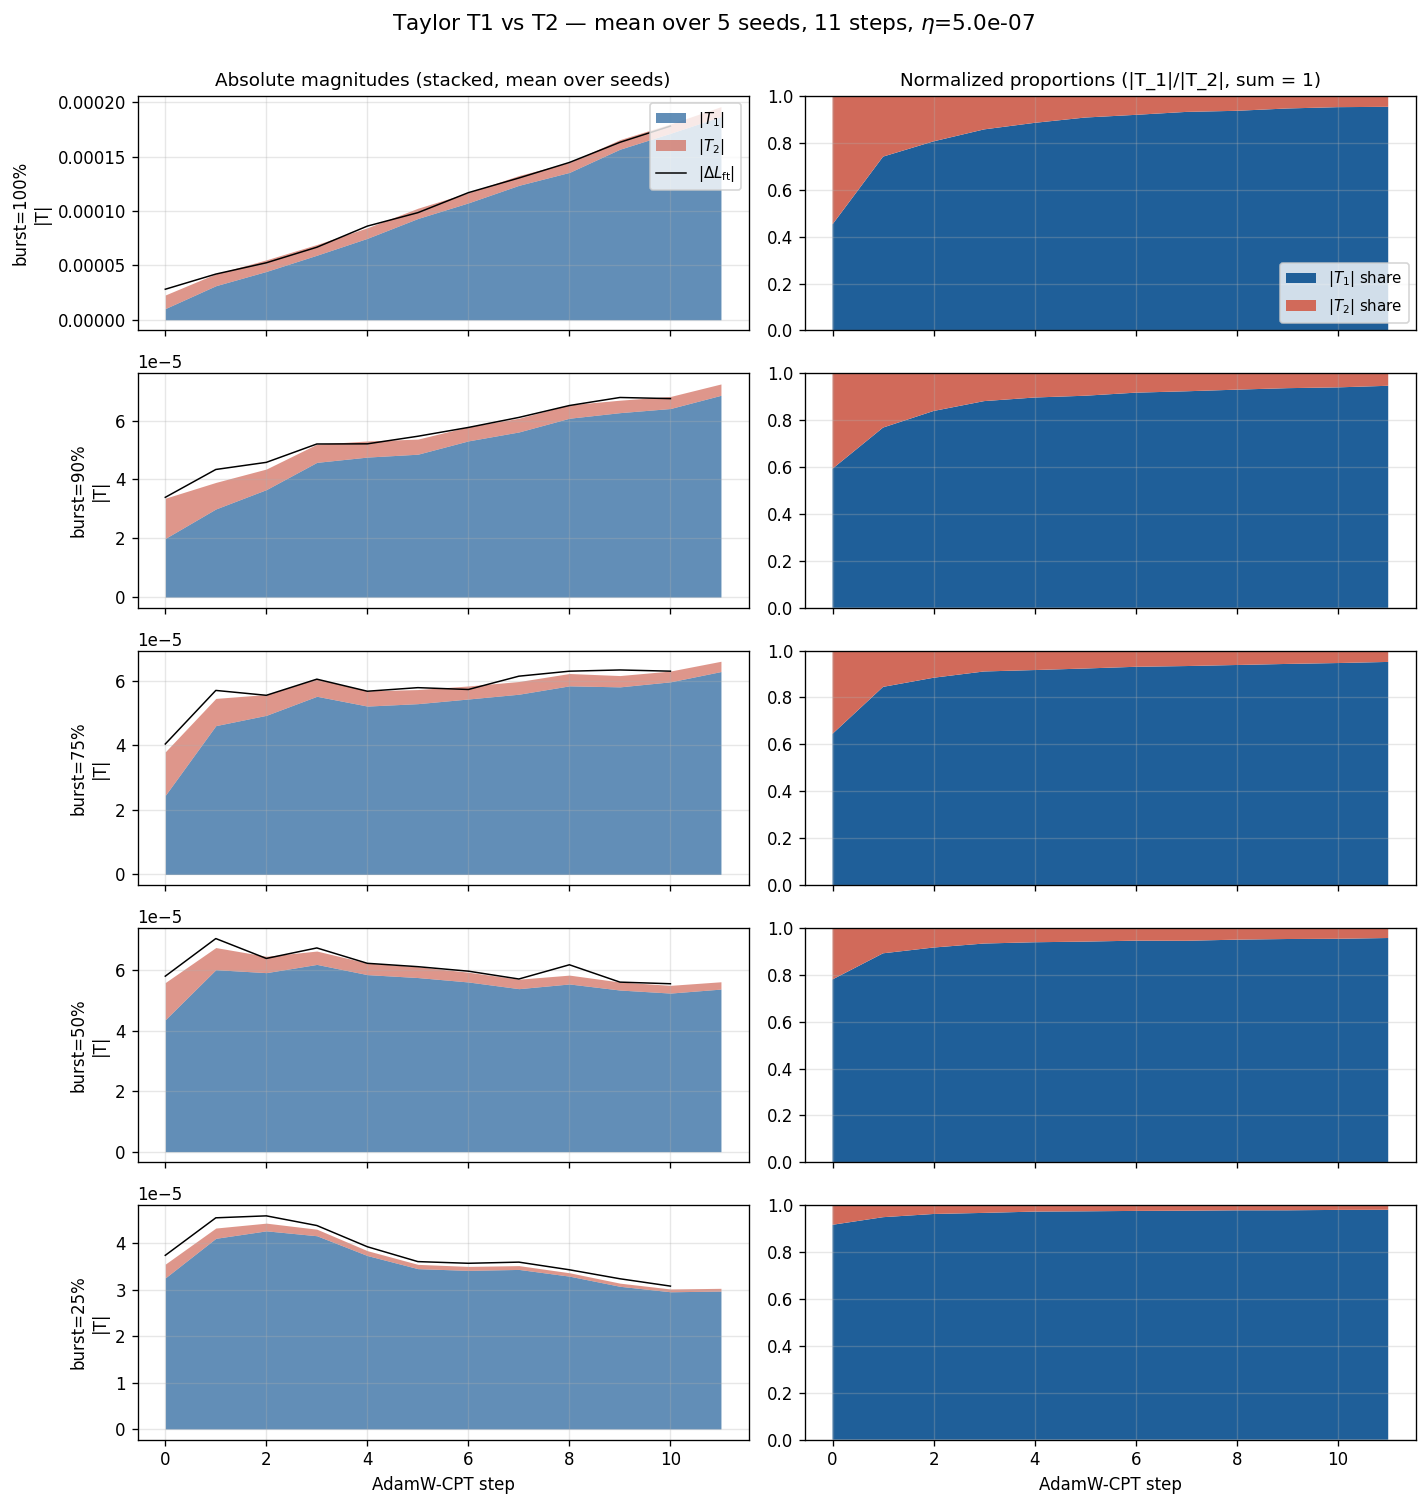

In [102]:
import pickle
from pathlib import Path

COL_T2 = "#1f5f99"   # first-order  (conflict)
COL_T4 = "#d16a5a"   # second-order (curvature)

bls_sorted = sorted(step_traces.keys(), reverse=True)
nrows = len(bls_sorted)

fig, axes = plt.subplots(nrows, 2, figsize=(12, 2.5 * nrows),
                         sharex=True, squeeze=False)

for i, bl in enumerate(bls_sorted):
    tr  = step_traces[bl]
    trs = step_traces_std[bl]
    steps = np.array([r["step"] for r in tr])
    aT2   = np.abs([r["T2"] for r in tr])
    aT4   = np.abs([r["T4"] for r in tr])
    sT2   = np.array([r["T2"] for r in trs])
    sT4   = np.array([r["T4"] for r in trs])
    tot   = aT2 + aT4
    NT2 = np.array([r["T2"] for r in tr])
    NT4 = np.array([r["T4"] for r in tr])
    safe  = np.where(tot > 0, tot, 1.0)
    fT2, fT4 = aT2 / safe, aT4 / safe

    # Actual ΔL = L(θ_{k+1}) − L(θ_k), measured from the recorded L_ft series.
    # Stored on each trace entry except the last (NaN there).
    dL    = np.array([r["dL_actual"] for r in tr])
    adL   = np.abs(dL)

    # Left: absolute magnitudes, stacked + std shading
    ax = axes[i, 0]
    ax.fill_between(steps, 0,   NT2,        color=COL_T2, linewidth=0, alpha=0.7,
                    label=(r"$|T_1|$" if i == 0 else None))
    ax.fill_between(steps, NT2, NT2 + NT4,  color=COL_T4, linewidth=0, alpha=0.7,
                    label=(r"$|T_2|$" if i == 0 else None))
    ax.plot(steps, adL, "k-", lw=0.9,
            label=(r"$|\Delta L_{\mathrm{ft}}|$" if i == 0 else None))
    # Std bands on individual terms
    # ax.fill_between(steps, np.maximum(aT2 - sT2, 0), aT2 + sT2,
    #                 color=COL_T2, alpha=0.15)
    # ax.fill_between(steps, np.maximum(aT4 - sT4, 0), aT4 + sT4,
    #                 color=COL_T4, alpha=0.15)
    ax.set_ylabel(f"burst={bl:.0%}\n|T|", fontsize=10)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_title("Absolute magnitudes (stacked, mean over seeds)", fontsize=11)
        ax.legend(fontsize=9, loc="upper right")
    ymax = max(np.nanmax(adL) if np.isfinite(np.nanmax(adL)) else 0.0,
               float(tot.max()))
    # ax.set_ylim(0, ymax * 1.2 if ymax > 0 else 1.0)

    # Right: normalized proportions
    ax = axes[i, 1]
    ax.stackplot(steps, fT2, fT4, colors=[COL_T2, COL_T4],
                 labels=[r"$|T_1|$ share", r"$|T_2|$ share"])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_title("Normalized proportions (|T_1|/|T_2|, sum = 1)", fontsize=11)
        ax.legend(fontsize=9, loc="lower right")

for ax in axes[-1]:
    ax.set_xlabel("AdamW-CPT step")

fig.suptitle(f"Taylor T1 vs T2 — mean over {len(SEEDS)} seeds, "
             f"{N_STEPS} steps, $\\eta$={ETA:.1e}",
             fontsize=13, y=1.00)
fig.tight_layout()

# Save
out_dir = Path(RESULTS_DIR) / "figures_adamw"
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / "cpt_taylor_sweep"
fig.savefig(fig_path.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), bbox_inches="tight", dpi=200)
with open(fig_path.with_suffix(".pkl"), "wb") as f:
    pickle.dump({"eta": ETA, "n_steps": N_STEPS, "seeds": SEEDS,
                 "traces_mean": step_traces, "traces_std": step_traces_std,
                 "seed_traces": seed_traces}, f)
print(f"saved: {fig_path.with_suffix('.pdf')}")
print(f"       {fig_path.with_suffix('.png')}")
print(f"       {fig_path.with_suffix('.pkl')}")
plt.show()


 z

---
## Why does the curvature term grow with $c$? Three candidate mechanisms

The AdamW curvature-damage term $\tfrac{1}{2}\, \Delta\theta^{\top} H_{\mathrm{ft}}\, \Delta\theta$ has two ingredients that can each change with burst concentration $c$: the Hessian $H_{\mathrm{ft}}$ and the actual update $\Delta\theta$ (which, unlike plain GD, is not proportional to $g_{\mathrm{pre}}$ because of Adam's moment estimates and decoupled weight decay). Three possible explanations for why the quadratic form grows with $c$:

1. **Directional curvature.** $H_{\mathrm{ft}}$ is sharper *specifically* along $\Delta\theta$ at high $c$. The basin is narrow in the exact direction AdamW pushes you.
2. **Isotropic sharpness.** $H_{\mathrm{ft}}$ is sharper *in all directions* at high $c$; $\Delta\theta$ just inherits that.
3. **Update magnitude.** $H_{\mathrm{ft}}$ is roughly unchanged, but $\|\Delta\theta\|$ grows with $c$, so the sandwich grows because the vector is longer.

**Diagnostic.** Measure three quantities at the post-FT checkpoint for each $c$:
- $\kappa_{\mathrm{dir}} = \hat{\Delta\theta}^{\top} H_{\mathrm{ft}}\, \hat{\Delta\theta}$ — Rayleigh quotient along the unit AdamW direction.
- $\lambda_{\mathrm{avg}} = \mathrm{Tr}(H_{\mathrm{ft}}) / d$ — average eigenvalue (Hutchinson).
- $\|\Delta\theta\|^2$ — squared norm of the AdamW step.

Read the bar chart below: if $\kappa_{\mathrm{dir}}$ grows with $c$ while $\lambda_{\mathrm{avg}}$ stays flat, forgetting is *anisotropic* and the AdamW step lines up with the sharp directions. If $\|\Delta\theta\|^2$ is the main mover, it's a magnitude story. Both can play a role.


In [103]:
# ── Hutchinson-trace estimator for Tr(H_ft) ─────────────────────────────
# Rademacher v ∈ {−1,+1}^d with v̂ = v/‖v‖ gives Tr(H)/d ≈ E[v̂^T H v̂].

N_HUTCH      = 30             # Rademacher probes per seed
MECH_SEEDS   = [0, 1]         # each seed = fresh Rademacher draw + fresh
                              # permutation of domain_valid (same convention
                              # as cell-run above). Set to [0] for the legacy
                              # single-seed behavior.
FD_EPS_HUTCH = 5e-3           # larger ε helps Hutchinson; random dirs are noise-limited

# κ_dir time-averaging knob — pull κ_domain from the first K_AVG steps of each
# cell-run seed and average. Justified because the AdamW direction at each
# early step is a *fresh sample* of a Rademacher-ish vector at θ ≈ θ_ft, so
# the K samples behave like Hutchinson probes. Adam's moments correlate them,
# so the effective sample count is < K_AVG (typically ~K_AVG/2).
K_AVG = 10

def hutchinson_trace(model, task_dataset,
                     n_samples=N_HUTCH, epsilon=FD_EPS_HUTCH,
                     batch_size=BSZ, num_batches=N_BATS, seed=0):
    d = sum(p.numel() for p in model.parameters() if p.requires_grad)
    gen = torch.Generator(device=device).manual_seed(seed)
    kappas = []
    for _ in range(n_samples):
        v = (torch.randint(0, 2, (d,), generator=gen, device=device).float() * 2 - 1)
        v_hat = v / v.norm()
        kappas.append(compute_kappa(model, v_hat, task_dataset,
                                    epsilon=epsilon,
                                    batch_size=batch_size,
                                    num_batches=num_batches))
    mean_kappa = float(np.mean(kappas))
    return d * mean_kappa, mean_kappa, d, kappas


# ── Per-burst diagnostic, averaged over MECH_SEEDS ──────────────────────
# κ_dir is now time-averaged over the first K_AVG cell-run steps per seed,
# then aggregated across cell-run SEEDS.  ||Δθ||² is taken at step 0 (the
# first AdamW step), with std propagated from cell-run.  λ_avg is computed
# here per MECH_SEED via Hutchinson.

mech_rows = []
for ckpt in sorted(glob.glob(os.path.join(RESULTS_DIR, "models", "burst_*/post_finetune"))):
    tag = os.path.basename(os.path.dirname(ckpt)).replace("burst_", "")
    bl  = float(tag.replace("_", "."))
    if bl not in step_traces or bl in EXCLUDE_BURSTS:
        continue

    print(f"\n{'─'*55}\nburst={bl:.0%}  [{ckpt}]")
    m = AutoModelForCausalLM.from_pretrained(
        os.path.abspath(ckpt), torch_dtype=torch.float32).to(device)
    m.eval()

    iso_per_seed, trace_per_seed, all_kappas = [], [], []
    d = None
    for SEED in MECH_SEEDS:
        rng  = torch.Generator().manual_seed(SEED)
        perm = torch.randperm(len(datasets["domain_valid"]), generator=rng).tolist()
        dv_seed = tud.Subset(datasets["domain_valid"], perm)
        trace_est, iso_sharp, d_seed, kappas = hutchinson_trace(m, dv_seed, seed=SEED)
        iso_per_seed.append(iso_sharp)
        trace_per_seed.append(trace_est)
        all_kappas.append(kappas)
        if d is None:
            d = d_seed
        print(f"    seed={SEED}: λ_avg={iso_sharp:.3e}  Tr(H)≈{trace_est:.3e}")

    del m
    if device == "cuda":
        torch.cuda.empty_cache()

    iso_mean   = float(np.mean(iso_per_seed))
    iso_std    = float(np.std(iso_per_seed))
    trace_mean = float(np.mean(trace_per_seed))

    # ── κ_dir: time-average over first K_AVG cell-run steps, per seed,
    #    then aggregate across cell-run SEEDS.
    kappa_per_seed_K   = []
    within_seed_step_std = []
    drifts_K           = []
    for cr_seed in SEEDS:
        if (cr_seed, bl) not in seed_traces:
            continue
        tr_k    = seed_traces[(cr_seed, bl)]
        K_used  = min(K_AVG, len(tr_k))
        if K_used == 0:
            continue
        vals    = [tr_k[k]["kappa_domain"] for k in range(K_used)]
        kappa_per_seed_K.append(float(np.mean(vals)))
        if K_used > 1:
            within_seed_step_std.append(float(np.std(vals, ddof=1)))
        drifts_K.append(float(tr_k[K_used - 1]["cum_drift"]))

    if kappa_per_seed_K:
        kappa_dir         = float(np.mean(kappa_per_seed_K))   # K-averaged, seed-pooled
        kappa_dir_std     = float(np.std(kappa_per_seed_K))    # across cell-run SEEDS
        kappa_step_noise  = float(np.mean(within_seed_step_std)) if within_seed_step_std else 0.0
        drift_K_mean      = float(np.mean(drifts_K))
        K_used_print      = min(K_AVG, len(seed_traces[(SEEDS[0], bl)]))
    else:
        kappa_dir = kappa_dir_std = kappa_step_noise = drift_K_mean = float("nan")
        K_used_print = 0

    s0              = step_traces[bl][0]
    s0_std          = step_traces_std[bl][0]
    dtheta_norm     = s0["dtheta_norm"]
    dtheta_norm_std = float(s0_std.get("dtheta_norm", 0.0))
    dtheta_sq       = dtheta_norm ** 2
    # Error propagation: δ(x²) ≈ 2x·δx
    dtheta_sq_std   = 2.0 * dtheta_norm * dtheta_norm_std
    quad            = dtheta_sq * kappa_dir

    mech_rows.append(dict(
        burst             = bl,
        lam_dir           = kappa_dir,             # time-averaged over K steps
        lam_dir_std       = kappa_dir_std,         # across cell-run SEEDS
        lam_dir_step_std  = kappa_step_noise,      # within-seed noise floor
        K_avg             = K_used_print,
        drift_K           = drift_K_mean,          # ||θ_K − θ_0||, sanity
        lam_iso           = iso_mean,
        lam_iso_std       = iso_std,
        dtheta_sq         = dtheta_sq,
        dtheta_sq_std     = dtheta_sq_std,
        quad_form         = quad,
        trace_est         = trace_mean,
        d                 = d,
        n_mech_seeds      = len(MECH_SEEDS),
        n_cellrun_seeds   = len(kappa_per_seed_K),
        n_hutch           = N_HUTCH,
        iso_per_seed      = iso_per_seed,
        kappa_per_seed_K  = kappa_per_seed_K,
        hutch_kappas      = all_kappas,
    ))
    print(f"  → κ_dir(K={K_used_print}) = {kappa_dir:.3f} "
          f"±{kappa_dir_std:.3f} (seeds)  "
          f"| step-noise={kappa_step_noise:.3f}  drift_K={drift_K_mean:.2e}")
    print(f"     λ_avg = {iso_mean:.3e} ±{iso_std:.1e}  "
          f"({len(MECH_SEEDS)} seeds × {N_HUTCH} probes)  |  "
          f"||Δθ||² = {dtheta_sq:.3e} ±{dtheta_sq_std:.1e}  |  "
          f"quad = {quad:.3e}   d = {d:,}")

mech_df = pd.DataFrame(mech_rows).sort_values("burst").reset_index(drop=True)
display(mech_df[["burst", "lam_dir", "lam_dir_std", "lam_dir_step_std",
                 "K_avg", "drift_K",
                 "lam_iso", "lam_iso_std",
                 "dtheta_sq", "dtheta_sq_std",
                 "quad_form", "trace_est", "d",
                 "n_mech_seeds", "n_cellrun_seeds"]])



───────────────────────────────────────────────────────
burst=25%  [results/20260425_131827_full_70m_biomedical/models/burst_0_25/post_finetune]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

    seed=0: λ_avg=1.232e-03  Tr(H)≈8.675e+04
    seed=1: λ_avg=1.281e-03  Tr(H)≈9.021e+04
  → κ_dir(K=10) = 0.527 ±0.052 (seeds)  | step-noise=0.069  drift_K=1.75e-02
     λ_avg = 1.256e-03 ±2.5e-05  (2 seeds × 30 probes)  |  ||Δθ||² = 1.261e-05 ±3.3e-08  |  quad = 6.646e-06   d = 70,426,624

───────────────────────────────────────────────────────
burst=50%  [results/20260425_131827_full_70m_biomedical/models/burst_0_50/post_finetune]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

    seed=0: λ_avg=4.547e-03  Tr(H)≈3.202e+05
    seed=1: λ_avg=4.030e-03  Tr(H)≈2.838e+05
  → κ_dir(K=10) = 1.872 ±0.069 (seeds)  | step-noise=0.157  drift_K=1.78e-02
     λ_avg = 4.289e-03 ±2.6e-04  (2 seeds × 30 probes)  |  ||Δθ||² = 1.284e-05 ±3.7e-08  |  quad = 2.404e-05   d = 70,426,624

───────────────────────────────────────────────────────
burst=75%  [results/20260425_131827_full_70m_biomedical/models/burst_0_75/post_finetune]


...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

    seed=0: λ_avg=3.241e-03  Tr(H)≈2.283e+05
    seed=1: λ_avg=4.578e-03  Tr(H)≈3.224e+05
  → κ_dir(K=10) = 2.519 ±0.066 (seeds)  | step-noise=0.339  drift_K=1.83e-02
     λ_avg = 3.909e-03 ±6.7e-04  (2 seeds × 30 probes)  |  ||Δθ||² = 1.279e-05 ±3.2e-08  |  quad = 3.223e-05   d = 70,426,624

───────────────────────────────────────────────────────
burst=100%  [results/20260425_131827_full_70m_biomedical/models/burst_1_00/post_finetune]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

    seed=0: λ_avg=4.573e-03  Tr(H)≈3.220e+05
    seed=1: λ_avg=4.765e-03  Tr(H)≈3.356e+05
  → κ_dir(K=10) = 2.988 ±0.037 (seeds)  | step-noise=0.448  drift_K=2.33e-02
     λ_avg = 4.669e-03 ±9.6e-05  (2 seeds × 30 probes)  |  ||Δθ||² = 1.177e-05 ±3.9e-08  |  quad = 3.516e-05   d = 70,426,624


,burst,lam_dir,lam_dir_std,lam_dir_step_std,K_avg,drift_K,lam_iso,lam_iso_std,dtheta_sq,dtheta_sq_std,quad_form,trace_est,d,n_mech_seeds,n_cellrun_seeds
0,0.25,0.526993,0.051978,0.069428,10,0.017488,0.001256,0.000025,0.000013,3.338003e-08,0.000007,88479.885706,70426624,2,5
1,0.50,1.871684,0.068996,0.157434,10,0.017844,0.004289,0.000258,0.000013,3.655410e-08,0.000024,302041.302604,70426624,2,5
2,0.75,2.260830,0.090612,0.246655,10,0.018014,0.004487,0.000327,0.000013,3.571251e-08,0.000029,316016.475294,70426624,2,5
3,0.90,2.519367,0.066260,0.338516,10,0.018320,0.003909,0.000668,0.000013,3.229286e-08,0.000032,275319.310136,70426624,2,5
4,1.00,2.988272,0.037459,0.447597,10,0.023253,0.004669,0.000096,0.000012,3.866027e-08,0.000035,328812.685194,70426624,2,5


saved: results/20260425_131827_full_70m_biomedical/figures_adamw/curvature_mechanism.pdf
       results/20260425_131827_full_70m_biomedical/figures_adamw/curvature_mechanism.png
       results/20260425_131827_full_70m_biomedical/figures_adamw/curvature_mechanism.csv
       results/20260425_131827_full_70m_biomedical/figures_adamw/curvature_mechanism.pkl


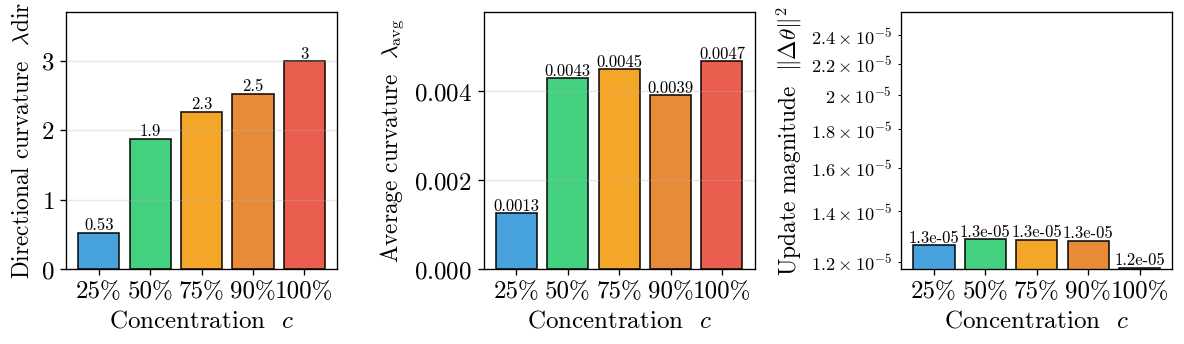


Relative change from lowest to highest c:
  κ_dir       : +467.0%
  λ_avg       : +271.6%
  ||Δθ||²     : -6.7%
  quad form   : +429.0%


In [104]:
# ── Plot: diagnostic quantities vs burst concentration c ──────────
bls_m       = mech_df["burst"].values
lam_dir_arr = mech_df["lam_dir"].values
lam_iso_arr = mech_df["lam_iso"].values
dtheta_sq   = mech_df["dtheta_sq"].values
quad_form   = mech_df["quad_form"].values

colors_b = [plot_module.BURST_COLORS.get(bl, "gray") for bl in bls_m]

_LATEX_RC = {
    'font.family'       : 'serif',
    'font.serif'        : ['cmr10', 'DejaVu Serif'],
    'mathtext.fontset'  : 'cm',
    'axes.formatter.use_mathtext': True,
    'axes.unicode_minus': False,
    'font.size'         : 11,
}

with plt.rc_context(_LATEX_RC):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    def _bars(ax, y, title, ylabel, scale='linear'):
        ax.bar(range(len(bls_m)), y, color=colors_b, edgecolor="black", alpha=0.9)
        ax.set_xticks(range(len(bls_m)))
        ax.set_xticklabels([f"{b:.0%}" for b in bls_m], fontsize=15)
        ax.set_xlabel("Concentration  $c$", fontsize=15)
        ax.set_ylabel(title, fontsize=14)
        ax.grid(axis="y", alpha=0.3)
        ax.set_yscale(scale)
        ax.tick_params(axis='both', labelsize=15)

        for i, v in enumerate(y):
            ax.text(i, v, f"{v:.2g}", ha="center",
                    va="bottom" if v >= 0 else "top", fontsize=10)
        # Headroom so value labels sit clearly inside the axes.
        ymin, ymax = ax.get_ylim()
        if scale == 'log':
            ax.set_ylim(ymin, ymax * 2.0)
        else:
            pad = (ymax - ymin) * 0.18
            ax.set_ylim(ymin, ymax + pad)

    _bars(axes[0], lam_dir_arr,
          r"Directional curvature  $\lambda{\mathrm{dir}}$",
          r"$\hat{\Delta\theta}^\top H_{\mathrm{ft}}\, \hat{\Delta\theta}$")
    _bars(axes[1], lam_iso_arr,
          r"Average curvature  $\lambda_{\mathrm{avg}}$",
          r"$\mathrm{Tr}(H_{\mathrm{ft}})/d$  (Hutchinson)")
    _bars(axes[2], dtheta_sq,
          r"Update magnitude  $\|\Delta\theta\|^2$",
          r"$\|\Delta\theta\|^2$", scale='log')

    fig.tight_layout()

    # Save to a separate figures_adamw/ dir so it doesn't collide with the GD notebook's outputs
    out_dir  = Path(RESULTS_DIR) / "figures_adamw"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig_path = out_dir / "curvature_mechanism"
    fig.savefig(fig_path.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(fig_path.with_suffix(".png"), bbox_inches="tight", dpi=200)
    mech_df.to_csv(fig_path.with_suffix(".csv"), index=False)
    with open(fig_path.with_suffix(".pkl"), "wb") as f:
        pickle.dump({"mech_df": mech_df.to_dict(orient="records"),
                     "n_hutch": N_HUTCH, "eta": ETA}, f)
    print(f"saved: {fig_path.with_suffix('.pdf')}")
    print(f"       {fig_path.with_suffix('.png')}")
    print(f"       {fig_path.with_suffix('.csv')}")
    print(f"       {fig_path.with_suffix('.pkl')}")
    plt.show()

def _rel_growth(y):
    y = np.asarray(y, dtype=float)
    lo, hi = y[0], y[-1]
    return (hi - lo) / (abs(lo) + 1e-30)

print("\nRelative change from lowest to highest c:")
print(f"  κ_dir       : {_rel_growth(lam_dir_arr):+.1%}")
print(f"  λ_avg       : {_rel_growth(lam_iso_arr):+.1%}")
print(f"  ||Δθ||²     : {_rel_growth(dtheta_sq):+.1%}")
print(f"  quad form   : {_rel_growth(quad_form):+.1%}")


saved: results/20260425_131827_full_70m_biomedical/figures_adamw/t1_share_step0.pdf
       results/20260425_131827_full_70m_biomedical/figures_adamw/t1_share_step0.png


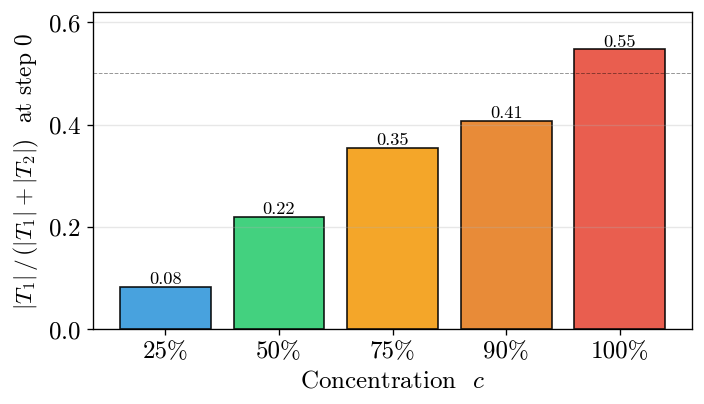

In [105]:
# ── Bar chart: |T_1| / (|T_1| + |T_2|) at step 0 per concentration ────
# Using the AdamW Taylor terms (stored as "T2"/"T4" trace keys).

bls_keep = [bl for bl in sorted(step_traces.keys()) if bl not in EXCLUDE_BURSTS]

shares, bar_labels, bar_colors = [], [], []
for bl in bls_keep:
    s0 = step_traces[bl][0]
    t1a, t2a = abs(s0["T2"]), abs(s0["T4"])
    denom = t1a + t2a
    shares.append(1 - t1a / denom if denom > 0 else np.nan)
    bar_labels.append(f"{bl:.0%}")
    bar_colors.append(plot_module.BURST_COLORS.get(bl, "gray"))

with plt.rc_context(_LATEX_RC):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    x = np.arange(len(bls_keep))
    ax.bar(x, shares, color=bar_colors, edgecolor="black", alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, fontsize=15)
    ax.set_xlabel("Concentration  $c$", fontsize=15)
    ax.set_ylabel(r"$|T_1|\,/\,(|T_1|+|T_2|)$  at step 0", fontsize=14)
    ax.axhline(0.5, color="k", lw=0.6, ls="--", alpha=0.4)
    ax.tick_params(axis="both", labelsize=15)
    ax.grid(axis="y", alpha=0.3)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, min(1.0, ymax) * 1.08)
    for i, v in enumerate(shares):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=11)
    fig.tight_layout()

    out_dir  = Path(RESULTS_DIR) / "figures_adamw"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig_path = out_dir / "t1_share_step0"
    fig.savefig(fig_path.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(fig_path.with_suffix(".png"), bbox_inches="tight", dpi=200)
    with open(fig_path.with_suffix(".pkl"), "wb") as f:
        pickle.dump({"bursts": bls_keep, "shares": shares,
                     "excluded": EXCLUDE_BURSTS}, f)
    print(f"saved: {fig_path.with_suffix('.pdf')}")
    print(f"       {fig_path.with_suffix('.png')}")
    plt.show()
